<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v1/blob/master/Model_MobileNetV3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model_MobileNetV3
Custom truncated MobileNetV3-Small style network trained from scratch on VWW.
Comparison against MobileNetV2 — same training protocol, different architecture.

**Key differences vs MobileNetV2:**
- Hard-swish activation (smoother than ReLU6)
- Squeeze-and-Excitation (SE) blocks on deeper layers
- Narrower channel widths → slightly fewer parameters

Run **Model_MobileNetV2** first if you want a direct comparison checkpoint.

In [1]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/stm32-thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place the utils/ folder at: My Drive/stm32-thesis/utils/")

Mounted at /content/drive
✅ utils loaded from Drive


In [2]:
# ── Imports ─────────────────────────────────────────────────────────
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from utils.dataset import prepare_dataset, get_loaders
from utils.models  import VWW_MobileNetV3, VWW_MobileNetV2, count_params, model_size_mb
from utils.train   import setup_device, set_seed, evaluate, train_multi_seed, plot_history

device = setup_device(seed=41)

Device: cuda


In [3]:
# ── Parameter count ─────────────────────────────────────────────────
m = VWW_MobileNetV3().to(device)
total, trainable = count_params(m)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")
print(f"Model size      : {model_size_mb(m):.2f} MB")
del m

Total params    : 139,428
Trainable params: 139,428
Model size      : 0.62 MB


In [4]:
prepare_dataset()
train_loader, val_loader = get_loaders(batch_size=64, augmentation="standard")

1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests
Train: 7000 | Val: 1500 | Batch: 64


In [5]:
SAVE_DIR = "/content/drive/My Drive/stm32-thesis/checkpoints"

In [6]:
results, best = train_multi_seed(
    model_fn     = VWW_MobileNetV3,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    seeds        = [41, 52, 63, 74, 85],
    save_dir     = SAVE_DIR,
    name_prefix  = "mobilenetv3",
    pretrained   = False,
    epochs          = 50,
    lr              = 1e-3,
    weight_decay    = 1e-4,
    label_smoothing = 0.1,
    patience        = 8,
)


Seed 41
Epoch   1/50 | LR 0.000999 | Train 58.69% | Val 58.60% ✅
Epoch   2/50 | LR 0.000996 | Train 65.40% | Val 61.00% ✅
Epoch   3/50 | LR 0.000991 | Train 67.00% | Val 69.27% ✅
Epoch   4/50 | LR 0.000984 | Train 69.31% | Val 67.33%
Epoch   5/50 | LR 0.000976 | Train 71.09% | Val 71.00% ✅
Epoch   6/50 | LR 0.000965 | Train 71.31% | Val 72.53% ✅
Epoch   7/50 | LR 0.000952 | Train 72.70% | Val 72.53%
Epoch   8/50 | LR 0.000938 | Train 72.71% | Val 69.80%
Epoch   9/50 | LR 0.000922 | Train 74.23% | Val 73.87% ✅
Epoch  10/50 | LR 0.000905 | Train 74.33% | Val 72.87%
Epoch  11/50 | LR 0.000885 | Train 74.69% | Val 74.73% ✅
Epoch  12/50 | LR 0.000864 | Train 75.34% | Val 74.33%
Epoch  13/50 | LR 0.000842 | Train 75.06% | Val 76.40% ✅
Epoch  14/50 | LR 0.000819 | Train 76.77% | Val 75.40%
Epoch  15/50 | LR 0.000794 | Train 76.84% | Val 73.13%
Epoch  16/50 | LR 0.000768 | Train 76.39% | Val 75.60%
Epoch  17/50 | LR 0.000741 | Train 76.81% | Val 75.87%
Epoch  18/50 | LR 0.000713 | Train 77.64

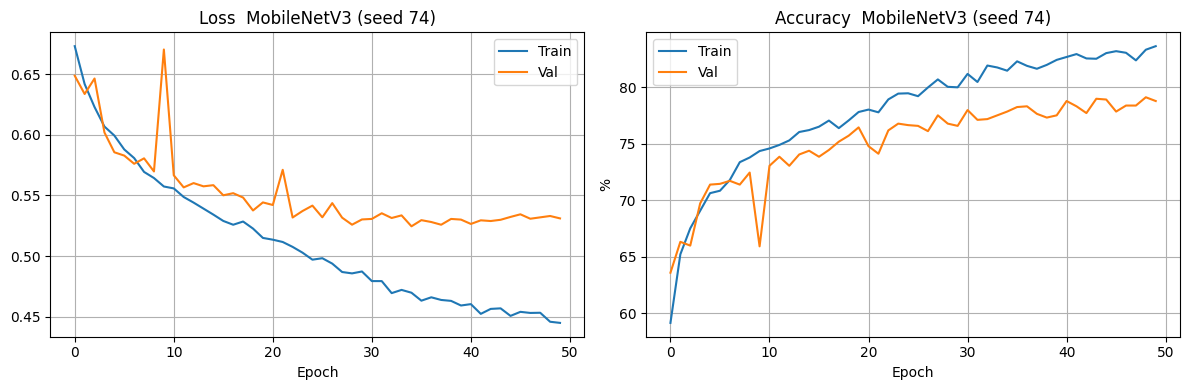

Best: 79.13% @ epoch 49  (13.5 min)

MobileNetV3  |  Mean: 78.33% ± 0.65%  |  Best: 79.13% (seed 74)
Best checkpoint: /content/drive/My Drive/stm32-thesis/checkpoints/mobilenetv3_seed_74.pth


In [7]:
plot_history(best, title=f"MobileNetV3 (seed {best['seed']})")

accs = [r["best_acc"] for r in results]
print(f"\nMobileNetV3  |  Mean: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%  |  Best: {best['best_acc']*100:.2f}% (seed {best['seed']})")
print(f"Best checkpoint: {best['save_path']}")

## MobileNetV2 vs MobileNetV3 comparison
Run `Model_MobileNetV2.ipynb` first, then come back here to compare.

In [8]:
# ── Compare V2 vs V3 val accuracy ───────────────────────────────────
V2_CKPT = f"{SAVE_DIR}/mobilenetv2_seed_85.pth"   # adjust seed if needed

if os.path.exists(V2_CKPT):
    v2 = VWW_MobileNetV2().to(device)
    v2.load_state_dict(torch.load(V2_CKPT, map_location=device))
    v2_acc = evaluate(v2, val_loader, device)

    v3 = VWW_MobileNetV3().to(device)
    v3.load_state_dict(torch.load(best["save_path"], map_location=device))
    v3_acc = evaluate(v3, val_loader, device)

    v2_params, _ = count_params(v2)
    v3_params, _ = count_params(v3)

    print("=" * 50)
    print(f"MobileNetV2  val acc: {v2_acc*100:.2f}%  params: {v2_params:,}")
    print(f"MobileNetV3  val acc: {v3_acc*100:.2f}%  params: {v3_params:,}")
    print(f"Accuracy delta      : {(v3_acc - v2_acc)*100:+.2f}%")
    print(f"Param delta         : {v3_params - v2_params:+,}")
    print("=" * 50)
else:
    print("⚠️  Run Model_MobileNetV2.ipynb first to get the V2 checkpoint")

MobileNetV2  val acc: 76.87%  params: 151,874
MobileNetV3  val acc: 79.13%  params: 139,428
Accuracy delta      : +2.27%
Param delta         : -12,446
